## Supralocal Interpretable Model Agnostic Explanations

Explain what this is here

Let's apply SLIME to the airfoil dataset.

In [8]:
import numpy as np
from pysr import *
from sklearn.datasets import fetch_openml

In [9]:
X, y = fetch_openml(
    name="airfoil_self_noise",  # OpenML dataset name
    version=1,
    as_frame=False,
    return_X_y=True
)
print(X.shape, y.shape)

(1503, 5) (1503,)


In this dataset, these are the input and target variables:

In [10]:
input_vars = [
    "Frequency", "Angle_of_attack", "Chord_length",
    "Free_stream_velocity", "Suction_side_displacement_thickness"
]
output_vars =["Scaled_sound_pressure_level"]

Let's train an XGBoost model on this dataset.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor

X_train, X_test,y_train, y_test = train_test_split(X, y)
xg_boost_model = GradientBoostingRegressor().fit(X_train, y_train)

Let's see how well the model performs.

In [12]:
from sklearn.metrics import r2_score, mean_squared_error

xg_boost_y_pred = xg_boost_model.predict(X_test)
print("Accuracy: ", r2_score(y_test, xg_boost_y_pred))

Accuracy:  0.8640301369780393


This gives us a pretty good R2 score, our model explains 85% of the variance in the dataset.

Wrap the model in a function, which is what `symtorch.SLIME` expects.

In [13]:
def f (inputs):
    return xg_boost_model.predict(inputs)

Let us estimate the behaviour of the model around a specific datapoint using LIME first.

In [17]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

def simple_lime(
    model,
    X_train,
    x0,
    n_samples=5000,
    J_neighbours=10,
    kernel_width=None,
    alpha=1.0,
    random_state=0,
    nn_metric='euclidean',
):
    """
    LIME-style local surrogate for regression around a single point x0.
    Uses the variance from J nearest neighbors to define the perturbation scale.
    
    This matches the neighborhood used by SLIME for fair comparison.
    """
    rng = np.random.default_rng(random_state)

    X_train = np.asarray(X_train)
    x0 = np.asarray(x0).reshape(1, -1)
    n_features = X_train.shape[1]

    # 1. Find J nearest neighbors and compute their variance
    nbrs = NearestNeighbors(n_neighbors=J_neighbours, metric=nn_metric).fit(X_train)
    _, indices = nbrs.kneighbors(x0)
    nearest_neighbors = X_train[indices[0]]
    
    # Use variance from nearest neighbors as perturbation scale
    sigma = np.std(nearest_neighbors, axis=0, ddof=1)
    sigma[sigma == 0] = 1e-6
    
    print(f"Using variance from {J_neighbours} nearest neighbors")
    print(f"Perturbation std: {sigma}")

    # 2. Sample neighbourhood around x0
    Z = x0 + rng.normal(0, sigma, size=(n_samples, n_features))

    # 3. Black-box predictions
    y_bb = model.predict(Z)

    # 4. Standardize the inputs (for Ridge regression stability)
    scaler = StandardScaler()
    Z_scaled = scaler.fit_transform(Z)
    x0_scaled = scaler.transform(x0)
    
    # 5. Proximity weights - compute in SCALED space
    dists = np.linalg.norm(Z_scaled - x0_scaled, axis=1)
    if kernel_width is None:
        kernel_width = np.sqrt(n_features) * 0.75  # Default LIME kernel width
    weights = np.exp(-(dists**2) / (kernel_width**2))

    # 6. Fit weighted linear surrogate
    lin = Ridge(alpha=alpha, fit_intercept=True)
    lin.fit(Z_scaled, y_bb, sample_weight=weights)

    # 7. Fidelity on the sampled neighbourhood
    y_lime = lin.predict(Z_scaled)
    r2 = r2_score(y_bb, y_lime, sample_weight=weights)  # Weighted R²
    mse = mean_squared_error(y_bb, y_lime, sample_weight=weights)  # Weighted MSE

    return {
        "surrogate": lin,
        "scaler": scaler,
        "r2": r2,
        "mse": mse,
        "coeffs": lin.coef_,
        "intercept": lin.intercept_,
        "x0": x0,
        "Z": Z,
        "weights": weights,
        "y_bb": y_bb,
        "y_lime": y_lime,
        "nearest_neighbors": nearest_neighbors,
        "sigma": sigma,
    }

print("=" * 60)
print("FITTING LIME MODEL (Linear Approximation)")
print("=" * 60)

np.random.seed(290402)
i = np.random.randint(0,len(X_test))

x0 = X_test[i]

res_lime = simple_lime(
    model=xg_boost_model,
    X_train=X_test,
    x0=x0,
    n_samples=10000,
    J_neighbours=10,
    random_state=290402,
)

print(f"\nLIME Local R² (weighted): {res_lime['r2']:.4f}")
print(f"LIME Local MSE (weighted): {res_lime['mse']:.4f}")
print(f"LIME Intercept: {res_lime['intercept']:.4f}")
print(f"LIME Coefficients: {res_lime['coeffs']}")
print(f"\nXGBoost prediction at x0: {xg_boost_model.predict(x0.reshape(1, -1))[0]:.4f}")
print(f"LIME prediction at x0: {res_lime['surrogate'].predict(res_lime['scaler'].transform(x0.reshape(1, -1)))[0]:.4f}")

FITTING LIME MODEL (Linear Approximation)
Using variance from 10 nearest neighbors
Perturbation std: [1.00000000e-06 4.74533689e+00 9.27863232e-02 2.49819935e+00
 1.99061805e-02]

LIME Local R² (weighted): 0.7322
LIME Local MSE (weighted): 3.8528
LIME Intercept: 127.7586
LIME Coefficients: [-9.94341268e-03  9.21141935e-03 -1.84023876e+00  1.17387094e-03
 -3.81651548e+00]

XGBoost prediction at x0: 130.7645
LIME prediction at x0: 127.7400


## Now Fit SLIME (Symbolic Regression)

Let's fit a SLIME model using the same J=10 nearest neighbors approach. SLIME will discover a symbolic equation that approximates the XGBoost model's behavior in this local region.

In [18]:
from symtorch.SLIME import SLIME, regressor_to_function

print("=" * 60)
print("FITTING SLIME MODEL (Symbolic Regression)")
print("=" * 60)

# Fit SLIME with J=10 nearest neighbors
# Use num_synthetic to add synthetic samples around x0
slime_regressor = SLIME(
    f=f,
    inputs=X_test,
    x=x0,
    num_synthetic=4990,  # 5000 - 10 synthetic samples
    J_neighbours=10,
    nn_metric='euclidean',
    pysr_params={
        'niterations': 500,
        'binary_operators': ['+', '*', '-', '/'],
        'unary_operators': ['sin', 'cos', 'exp', 'log', 'sqrt'],
        'complexity_of_operators': {'sin': 3, 'cos': 3, 'exp': 3, 'log': 3, 'sqrt': 2},
    }
)

print("\n" + "=" * 60)
print("SLIME RESULTS")
print("=" * 60)
print("\nTop 5 equations found by SLIME:")
print(slime_regressor.equations_[['complexity', 'loss', 'score', 'equation']].head(10))

/Users/liz/PhD/SymTorch_project/SymTorch/src/symtorch/SLIME.py:79: RuntimeWarning: invalid value encountered in divide
  synthetic_distances_sq = np.sum((samples - x)**2 / var, axis=1)
/Users/liz/PhD/SymTorch_project/symtorch_venv/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...


FITTING SLIME MODEL (Symbolic Regression)
Fitting SLIME with 5000 points including 10 real points and 4990 Gaussian sampled points.


[ Info: Started!



Expressions evaluated per second: 1.680e+05
Progress: 968 / 15500 total iterations (6.245%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.228e+01  0.000e+00  y = 126.94
3           2.197e+01  7.060e-03  y = 126.99 - x₂
5           8.588e+00  4.696e-01  y = (x₄ * -188.07) - -127.24
7           8.278e+00  1.838e-02  y = (127.29 - (x₄ * 188.05)) - x₂
8           7.843e+00  5.396e-02  y = 128.11 * (cos(x₂) - x₄)
9           7.038e+00  1.083e-01  y = (128.16 - (128.16 * x₄)) - (x₂ / 0.054577)
10          6.341e+00  1.043e-01  y = 138.12 - (exp(x₄ * 17.586) * 10.255)
11          5.520e+00  1.388e-01  y = 128.47 - (x₄ * (x₀ * ((x₄ * 1.6017) + 0.088007)))
12          3.571e+00  4.354e-01  y = 141.06 - (exp((x₄ * 14.277) + x₂) * 12.56)
13          3.225e+00  1.019e-01  y = 129.39 - (((

[ Info: Final population:
[ Info: Results saved to:



SLIME RESULTS

Top 5 equations found by SLIME:
   complexity       loss     score  \
0           1  22.281480  0.000000   
1           3  21.969013  0.007061   
2           5   8.587923  0.469638   
3           7   8.277921  0.018383   
4           8   7.792625  0.060414   
5           9   5.519593  0.344874   
6          11   5.209317  0.028928   
7          12   3.567563  0.378566   
8          13   2.464821  0.369763   
9          15   2.455169  0.001962   

                                            equation  
0                                          126.93825  
1                                     126.98793 - x2  
2                      (x4 * -188.0651) - -127.24052  
3                (127.29053 - (x4 * 188.04845)) - x2  
4                         (cos(x2) - x4) * 127.88329  
5  128.46983 - ((-0.0549409 - x4) * (x4 * -3203.4...  
6  (128.5199 - ((x4 * (-0.054930802 - x4)) * -320...  
7  140.64641 - (exp(x2 + (x4 * 14.858986)) * 12.1...  
8  129.28294 - ((x4 + (x2 * 0.10596767

In [19]:
# Get the best SLIME equation and convert to a callable function
slime_func, slime_vars = regressor_to_function(slime_regressor)
best_equation = slime_regressor.get_best()['equation']

print(f"Best SLIME equation: {best_equation}")
print(f"Variables used: {slime_vars}")
print(f"Number of variables: {len(slime_vars)}")

# Evaluate both models on the sampled neighborhood from LIME
Z = res_lime['Z']  # The sampled points around x0
y_true = res_lime['y_bb']  # XGBoost predictions on these points
weights = res_lime['weights']  # Gaussian kernel weights

# LIME predictions (linear model)
Z_scaled = res_lime['scaler'].transform(Z)
y_lime_pred = res_lime['surrogate'].predict(Z_scaled)

# SLIME predictions (symbolic equation)
# Extract variable indices from variable names (e.g., 'x2' -> 2)
var_indices = [int(str(v).replace('x', '')) for v in slime_vars]
print(f"Variable indices used by SLIME: {var_indices}")

# Pass only the features that appear in the equation
Z_slime = [Z[:, idx] for idx in var_indices]
y_slime_pred = slime_func(*Z_slime)

# Calculate R² and MSE for both models (weighted)
lime_r2 = r2_score(y_true, y_lime_pred, sample_weight=weights)
lime_mse = mean_squared_error(y_true, y_lime_pred, sample_weight=weights)

slime_r2 = r2_score(y_true, y_slime_pred, sample_weight=weights)
slime_mse = mean_squared_error(y_true, y_slime_pred, sample_weight=weights)

print("\n" + "=" * 60)
print("COMPARISON ON SAMPLED NEIGHBORHOOD (n={})".format(len(Z)))
print("=" * 60)
print(f"\nLIME (Linear Model - uses all {Z.shape[1]} features):")
print(f"  R²:  {lime_r2:.4f}")
print(f"  MSE: {lime_mse:.4f}")

print(f"\nSLIME (Symbolic Equation - uses {len(slime_vars)} features: {[input_vars[i] for i in var_indices]}):")
print(f"  R²:  {slime_r2:.4f}")
print(f"  MSE: {slime_mse:.4f}")

if slime_r2 > lime_r2:
    print(f"\n✓ SLIME is better by {((slime_r2 - lime_r2) / max(abs(lime_r2), 1e-10)) * 100:.1f}% in R²")
else:
    print(f"\n✓ LIME is better by {((lime_r2 - slime_r2) / max(abs(slime_r2), 1e-10)) * 100:.1f}% in R²")

# Test predictions at x0
x0_scaled = res_lime['scaler'].transform(x0.reshape(1, -1))
lime_at_x0 = res_lime['surrogate'].predict(x0_scaled)[0]
slime_at_x0 = slime_func(*[x0.flatten()[idx] for idx in var_indices])
xgboost_at_x0 = xg_boost_model.predict(x0.reshape(1, -1))[0]

print(f"\n" + "=" * 60)
print("PREDICTIONS AT x0")
print("=" * 60)
print(f"XGBoost:  {xgboost_at_x0:.4f}")
print(f"LIME:     {lime_at_x0:.4f}  (error: {abs(lime_at_x0 - xgboost_at_x0):.4f})")
print(f"SLIME:    {slime_at_x0:.4f}  (error: {abs(slime_at_x0 - xgboost_at_x0):.4f})")

Best SLIME equation: cos(x2) * (129.81142 - (((x4 * -13.487559) - x2) * (-12.153753 - (x4 * 242.86954))))
Variables used: [x2, x4]
Number of variables: 2
Variable indices used by SLIME: [2, 4]

COMPARISON ON SAMPLED NEIGHBORHOOD (n=10000)

LIME (Linear Model - uses all 5 features):
  R²:  0.7322
  MSE: 3.8528

SLIME (Symbolic Equation - uses 2 features: ['Chord_length', 'Suction_side_displacement_thickness']):
  R²:  0.8942
  MSE: 1.5220

✓ SLIME is better by 22.1% in R²

PREDICTIONS AT x0
XGBoost:  130.7645
LIME:     127.7400  (error: 3.0245)
SLIME:    128.7509  (error: 2.0136)


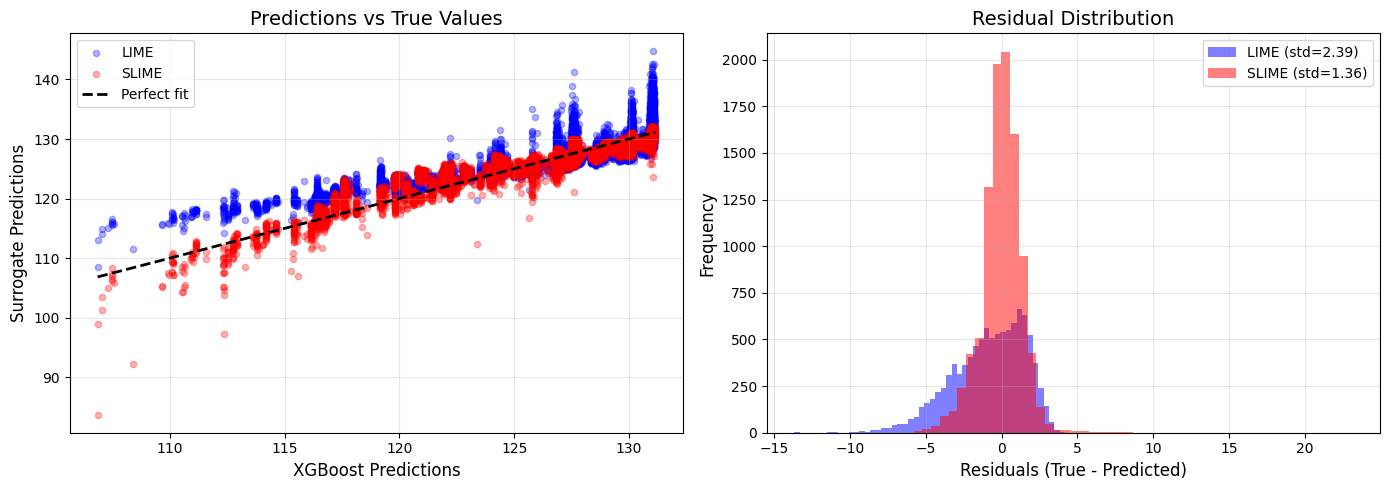


Residual Statistics:
LIME:  Mean = -0.8583, Std = 2.3938
SLIME: Mean = -0.0063, Std = 1.3606


In [20]:
import matplotlib.pyplot as plt

# Create visualization comparing LIME and SLIME predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predictions vs True values
ax1 = axes[0]
ax1.scatter(y_true, y_lime_pred, alpha=0.3, s=20, label='LIME', c='blue')
ax1.scatter(y_true, y_slime_pred, alpha=0.3, s=20, label='SLIME', c='red')
ax1.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2, label='Perfect fit')
ax1.set_xlabel('XGBoost Predictions', fontsize=12)
ax1.set_ylabel('Surrogate Predictions', fontsize=12)
ax1.set_title('Predictions vs True Values', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Residuals
ax2 = axes[1]
lime_residuals = y_true - y_lime_pred
slime_residuals = y_true - y_slime_pred
ax2.hist(lime_residuals, bins=50, alpha=0.5, label=f'LIME (std={np.std(lime_residuals):.2f})', color='blue')
ax2.hist(slime_residuals, bins=50, alpha=0.5, label=f'SLIME (std={np.std(slime_residuals):.2f})', color='red')
ax2.set_xlabel('Residuals (True - Predicted)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Residual Distribution', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nResidual Statistics:")
print(f"LIME:  Mean = {np.mean(lime_residuals):.4f}, Std = {np.std(lime_residuals):.4f}")
print(f"SLIME: Mean = {np.mean(slime_residuals):.4f}, Std = {np.std(slime_residuals):.4f}")